Github link:https://github.com/Jayanth-nr19/Machine_Learning_and-Neural_Networks

# Clustering Spotify Songs Using K-Means

##  Introduction

This notebook applies K-Means clustering to Spotify audio features to identify hidden patterns in musical data. The objective is to group songs into clusters based on their characteristics without using labelled data.

The analysis focuses on determining the optimal number of clusters using the Elbow Method and evaluating the importance of feature scaling. Principal Component Analysis (PCA) is used to visualise clusters in a reduced-dimensional space.

## Import Libraries

This section imports the necessary Python libraries required for data processing, visualisation, and machine learning.

- **Pandas** is used for data manipulation and analysis  
- **NumPy** provides support for numerical operations  
- **Matplotlib** is used for creating visualisations  
- **Scikit-learn** provides tools for preprocessing, clustering, and dimensionality reduction  

These libraries form the foundation of the analysis and enable the implementation of K-Means clustering and associated techniques.

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from math import pi
from sklearn.metrics import silhouette_samples, silhouette_score


## Data Loading

The dataset is loaded using the Pandas library. It contains Spotify audio features for a large number of tracks, which will be used for clustering analysis.

The `read_csv()` function is used to import the dataset into a DataFrame, allowing efficient data manipulation and exploration. The first few rows of the dataset are displayed to verify that the data has been loaded correctly.

In [66]:
df = pd.read_csv("SpotifyFeatures.csv")

df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,04-Apr,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,04-Apr,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,05-Apr,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,04-Apr,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,04-Apr,0.390


## Feature Selection and Data Preprocessing

A subset of numerical audio features was selected for clustering analysis. These include attributes such as acousticness, energy, tempo, and valence, which describe different aspects of musical content.

Additionally, track duration (`duration_ms`) was included as it provides further information about the structure of songs. Although this feature has a larger scale compared to others, it is standardised during preprocessing to ensure it does not disproportionately influence the clustering process.

Non-numerical attributes such as artist names and track identifiers were excluded, as K-Means clustering requires numerical input. Missing values were removed to maintain data consistency.

In [67]:
features = df[['danceability','energy','loudness','speechiness',
               'acousticness','instrumentalness','liveness',
               'valence','tempo']]

data = features.copy()

# Remove missing values
data = data.dropna()
data.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.389,0.910,-1.828,0.0525,0.611,0.000,0.3460,0.814,166.969
1,0.590,0.737,-5.559,0.0868,0.246,0.000,0.1510,0.816,174.003
2,0.663,0.131,-13.879,0.0362,0.952,0.000,0.1030,0.368,99.488
3,0.240,0.326,-12.178,0.0395,0.703,0.000,0.0985,0.227,171.758
4,0.331,0.225,-21.150,0.0456,0.950,0.123,0.2020,0.390,140.576


##  Feature Scaling

Feature scaling is a critical step in K-Means clustering, as the algorithm relies on distance-based calculations (typically Euclidean distance). If features are on different scales, variables with larger magnitudes can dominate the clustering process, leading to biased results.

To address this issue, standardisation is applied using the StandardScaler. This transforms each feature so that it has a mean of zero and a standard deviation of one, ensuring that all variables contribute equally to the clustering process.

This step is particularly important in this dataset, as features such as track duration and tempo have significantly larger ranges compared to attributes like danceability or acousticness.

In [68]:
# Apply standardisation
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Convert back to DataFrame for easier inspection
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

scaled_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,-0.890935,1.286908,1.290703,-0.367970,0.683376,-0.489819,0.660661,1.380744,1.595607
1,0.191994,0.630249,0.668683,-0.183082,-0.345467,-0.489819,-0.322835,1.388435,1.823253
2,0.585296,-1.669954,-0.718402,-0.455832,1.644570,-0.489819,-0.564927,-0.334212,-0.588326
3,-1.693703,-0.929789,-0.434817,-0.438044,0.942701,-0.489819,-0.587623,-0.876384,1.750597
4,-1.203422,-1.313157,-1.930601,-0.405163,1.638932,-0.083566,-0.065613,-0.249618,0.741433


##  Determining the Optimal Number of Clusters

Selecting an appropriate number of clusters (K) is a critical step in K-Means clustering. An incorrect choice can lead to either overfitting (too many clusters) or underfitting (too few clusters).

The **Elbow Method** is used to identify the optimal value of K by analysing the relationship between the number of clusters and the inertia. Inertia represents the sum of squared distances between data points and their assigned cluster centroids.

As the number of clusters increases, inertia decreases. However, beyond a certain point, the rate of decrease slows significantly. This point, known as the "elbow", indicates a suitable number of clusters for the dataset.

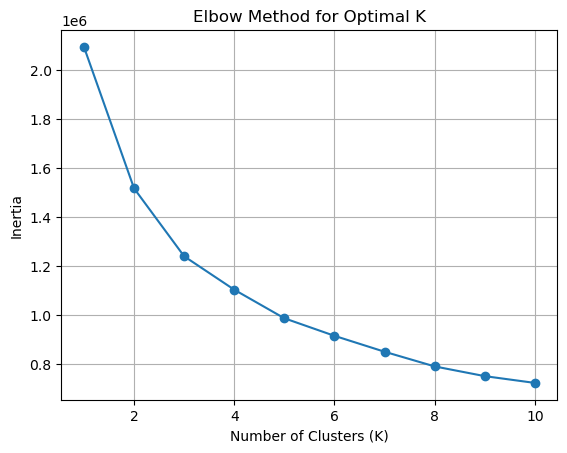

In [111]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.savefig("Elbow Method.png")
plt.grid()
plt.show()

From the elbow plot, the optimal number of clusters is identified at the point where the decrease in inertia begins to level off. In this analysis, this occurs at approximately **K = 4**, indicating that four clusters provide a suitable balance between model simplicity and clustering performance.

## Validating Cluster Quality: Silhouette Analysis
While the Elbow Method (Inertia) provides a mechanical view of how tight our clusters are, it doesn't account for how well-separated the groups are from one another. To provide a more robust technical justification for choosing $k=4$, we implement **Silhouette Analysis**.

The Silhouette Coefficient is a measure of how similar an object is to its own cluster (cohesion) compared to other clusters (separation). 

* **Value close to +1:** Indicates the sample is far from neighboring clusters.
* **Value of 0:** Indicates the sample is on or very close to the decision boundary.
* **Negative value:** Indicates the sample might be assigned to the wrong cluster.

By visualizing these "silhouettes," we can assess if our clusters are truly distinct or if the overlap suggests that music genres exist more as a gradient than as rigid categories.

For n_clusters = 4, the average silhouette_score is: 0.2216


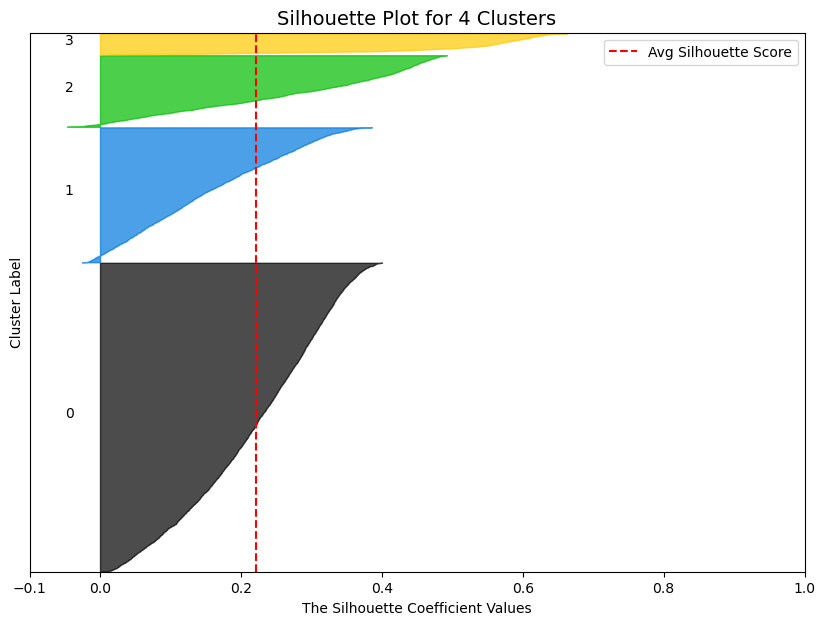

In [112]:
def plot_silhouette_analysis(X, cluster_labels):
    n_clusters = len(np.unique(cluster_labels))
    
    # Create a subplot with 1 row and 1 column
    fig, ax1 = plt.subplots(figsize=(10, 7))

    # The silhouette coefficient can range from -1, 1
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Compute the average silhouette score
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg:.4f}")

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate and sort scores for samples in cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10 

    ax1.set_title(f"Silhouette Plot for {n_clusters} Clusters", fontsize=14)
    ax1.set_xlabel("The Silhouette Coefficient Values")
    ax1.set_ylabel("Cluster Label")

    # The vertical line for average silhouette score
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label='Avg Silhouette Score')
    ax1.set_yticks([]) # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.legend()
    plt.savefig("silhouette.png")
    plt.show()

# Since the Spotify dataset is large, we use a 10,000 song sample for visualization efficiency
sample_size = 10000
indices = np.random.choice(range(len(scaled_data)), sample_size, replace=False)

# Pass the sampled scaled data and the corresponding cluster labels
plot_silhouette_analysis(scaled_data[indices], data['Cluster'].iloc[indices])

##  K-Means Clustering

Based on the Elbow Method, the optimal number of clusters was determined to be **K = 4**. This value provides a balance between minimising inertia and avoiding unnecessary model complexity.

The K-Means algorithm is applied to the scaled dataset to partition the data into four distinct clusters. Each data point is assigned to the nearest cluster centroid based on Euclidean distance.

The resulting cluster labels are added to the dataset, enabling further analysis and interpretation of the grouped data.

In [70]:
# Define number of clusters
k = 4

# Apply K-Means
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
data['Cluster'] = clusters

# Preview result
data.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,0.389,0.910,-1.828,0.0525,0.611,0.000,0.3460,0.814,166.969,0
1,0.590,0.737,-5.559,0.0868,0.246,0.000,0.1510,0.816,174.003,0
2,0.663,0.131,-13.879,0.0362,0.952,0.000,0.1030,0.368,99.488,1
3,0.240,0.326,-12.178,0.0395,0.703,0.000,0.0985,0.227,171.758,1
4,0.331,0.225,-21.150,0.0456,0.950,0.123,0.2020,0.390,140.576,2


## Data Exploration (EDA)

Before applying K-Means Clustering, it is important to understand the structure and characteristics of the dataset. This step helps identify potential issues such as missing values, incorrect data types, or extreme values that could affect the clustering results.

We begin by examining the dataset using basic functions:

- `df.info()` to understand the data types and check for missing values  
- `df.describe()` to view summary statistics such as mean, standard deviation, and range  
- `df.head()` to preview the first few rows of the dataset  

Since K-Means relies on distance calculations, it is particularly sensitive to the scale and distribution of features. Therefore, during this step we also pay attention to:

- The range of each feature (e.g., tempo vs danceability)  
- Whether any features dominate due to larger numerical values  
- The overall distribution of the data  

This exploration provides important insights that guide preprocessing decisions, especially the need for feature scaling before applying the clustering algorithm.

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [72]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


## Cluster Distribution

After applying K-Means clustering, it is important to examine the distribution of data points across clusters. This helps to ensure that the clusters are reasonably balanced and that no cluster is disproportionately large or small.

A highly imbalanced distribution may indicate that the chosen number of clusters is not optimal or that the data does not naturally form well-separated groups.

Cluster
0    132997
1     58599
2     30904
3     10225
Name: count, dtype: int64


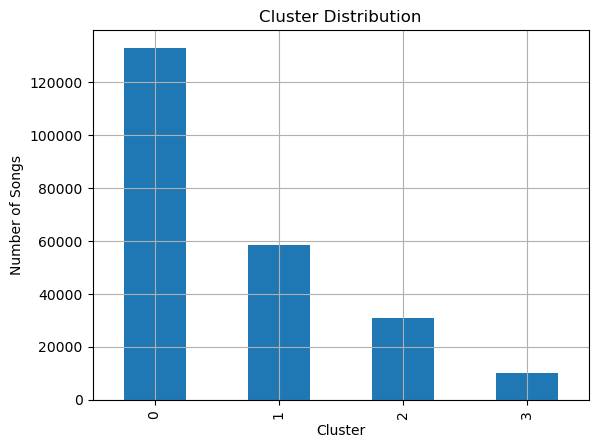

In [113]:
# Sorted cluster sizes
cluster_sizes = data['Cluster'].value_counts().sort_index()

print(cluster_sizes)
cluster_sizes.plot(kind='bar')

plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.title("Cluster Distribution")
plt.grid()
plt.savefig("cluster distribution")
plt.show()


In [74]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

The cluster distribution shows how songs are allocated across the four clusters. A relatively balanced distribution suggests that the clustering model has effectively partitioned the dataset. 

If one cluster were significantly larger than the others, it could indicate that the data is not well separated or that a different value of K may be more appropriate.

## Cluster Analysis

To better understand the characteristics of each cluster, the mean values of the features are calculated for each group. These values represent the average properties of songs within each cluster.

By analysing these averages, it is possible to identify the defining characteristics of each cluster and interpret the types of songs that belong to each group.

In [75]:
cluster_summary = data.groupby('Cluster').mean()
cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,
0,0.615968,0.739369,-6.208145,0.101219,0.122846,0.067040,0.208740,0.558115,124.702471
1,0.552840,0.388252,-10.905252,0.072659,0.596951,0.088330,0.170984,0.387656,113.102195
2,0.289612,0.162010,-20.712035,0.047059,0.854799,0.660355,0.155329,0.151721,102.459934
3,0.562013,0.663502,-11.967272,0.873460,0.786080,0.001335,0.729247,0.414462,98.269352


##  Visualisation using Principal Component Analysis (PCA)

Since the dataset contains multiple features, it is difficult to visualise clusters directly in high-dimensional space. To address this, **Principal Component Analysis (PCA)** is applied to reduce the data to two dimensions while preserving as much variance as possible.

The transformed data is then plotted to visually assess how well the clusters are separated. Each point represents a song, and colours indicate cluster membership.

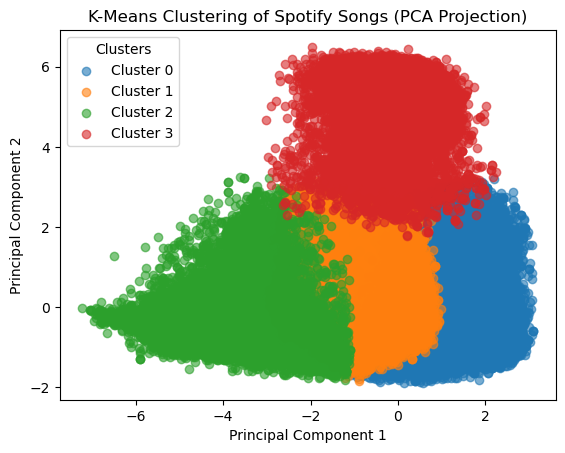

In [76]:
plt.figure()

for cluster in range(k):
    subset = pca_df[pca_df['Cluster'] == cluster]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Spotify Songs (PCA Projection)")
plt.legend(title="Clusters")
plt.savefig("K-Means Clustering of Spotify Songs (PCA Projection)")
plt.show()

## Normalised Feature Comparison Across Clusters

To improve the interpretability of the cluster comparison, feature values were normalised using the MinMaxScaler. This technique rescales all features to a common range between 0 and 1.

This step is particularly important because some variables, such as track duration (`duration_ms`), have significantly larger magnitudes compared to other features like danceability or acousticness. Without normalisation, these large-scale features would dominate the visualisation and obscure meaningful comparisons.

By applying normalisation, all features contribute equally to the plot, allowing clearer identification of differences between clusters. This provides a more balanced and interpretable comparison of cluster characteristics.

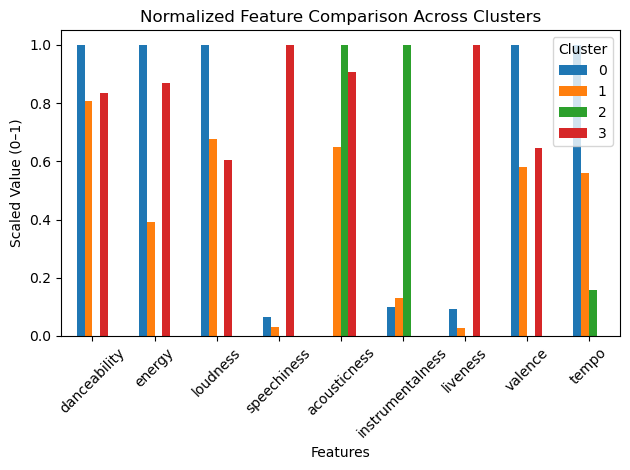

In [77]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized = scaler.fit_transform(cluster_summary)

normalized_df = pd.DataFrame(normalized, columns=cluster_summary.columns)

normalized_df.T.plot(kind='bar')

plt.title("Normalized Feature Comparison Across Clusters")
plt.xlabel("Features")
plt.ylabel("Scaled Value (0–1)")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cluster Summary (Ordered)

The cluster summary is sorted by cluster index to improve readability and consistency. This ensures that clusters are presented in a logical order (e.g., Cluster 0 to Cluster 3), making it easier to compare their characteristics.

Organising the results in this way supports clearer interpretation and enhances the overall presentation of the analysis.

In [102]:
cluster_summary = features.copy()
cluster_summary['cluster'] = clusters

cluster_summary = cluster_summary.groupby('cluster').mean()
cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.615968,0.739369,-6.208145,0.101219,0.122846,0.067040,0.208740,0.558115,124.702471
1,0.552840,0.388252,-10.905252,0.072659,0.596951,0.088330,0.170984,0.387656,113.102195
2,0.289612,0.162010,-20.712035,0.047059,0.854799,0.660355,0.155329,0.151721,102.459934
3,0.562013,0.663502,-11.967272,0.873460,0.786080,0.001335,0.729247,0.414462,98.269352


## 10. Cluster Centroids 

The cluster centroids represent the central point of each cluster in the feature space. Since K-Means was applied to standardised data, the centroid values are initially in the scaled space.

To make these values interpretable, the centroids are transformed back to the original scale using the inverse transformation of the StandardScaler. This allows the feature values to be understood in their original units.

These centroid values provide a clear summary of the typical characteristics of each cluster and can be used to interpret the nature of the grouped songs.

In [99]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features.columns
)
centroids = centroids.round(2)
centroids

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.40,0.53,-12.57,-0.04,-0.38,-0.18,0.14,0.31,104.31
1,0.29,-0.24,-23.91,-0.17,0.59,-0.13,0.03,0.05,94.35
2,-0.18,-0.73,-47.64,-0.28,1.13,1.11,-0.02,-0.32,85.27
3,0.30,0.36,-26.51,3.40,0.98,-0.32,1.64,0.09,81.68


## Detailed Cluster Inspection

To further analyse the characteristics of each cluster, the feature values for each group are displayed individually. This allows a more detailed examination of how each cluster differs across the selected audio features.

By reviewing clusters one at a time, it becomes easier to identify patterns and assign meaningful interpretations to each group of songs.

In [100]:
for i in range(k):
    print(f"\nCluster {i} summary:")
    print(cluster_summary.loc[i])


Cluster 0 summary:
danceability          0.615968
energy                0.739369
loudness             -6.208145
speechiness           0.101219
acousticness          0.122846
instrumentalness      0.067040
liveness              0.208740
valence               0.558115
tempo               124.702471
Name: 0, dtype: float64

Cluster 1 summary:
danceability          0.552840
energy                0.388252
loudness            -10.905252
speechiness           0.072659
acousticness          0.596951
instrumentalness      0.088330
liveness              0.170984
valence               0.387656
tempo               113.102195
Name: 1, dtype: float64

Cluster 2 summary:
danceability          0.289612
energy                0.162010
loudness            -20.712035
speechiness           0.047059
acousticness          0.854799
instrumentalness      0.660355
liveness              0.155329
valence               0.151721
tempo               102.459934
Name: 2, dtype: float64

Cluster 3 summary:
danceabilit

##  Feature Comparison Across Clusters

To improve the clarity of the cluster comparison, the feature `duration_ms` was excluded from the visualisation. This feature has a significantly larger scale than the other variables, which can distort the bar chart and make it difficult to interpret differences between features.

The remaining features are plotted to compare their average values across clusters. Each bar represents the mean value of a feature within a cluster, allowing for a clear visual comparison of cluster characteristics.

This adjusted visualisation provides a more balanced and interpretable representation of the data, enabling better identification of patterns and differences between clusters.

<Figure size 1200x600 with 0 Axes>

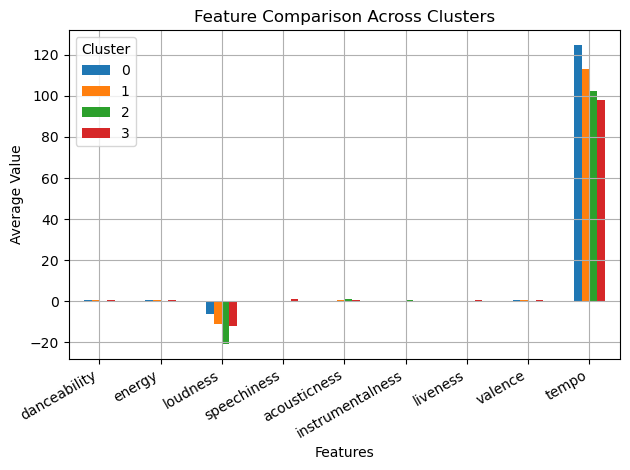

In [95]:
plt.figure(figsize=(12, 6))

cluster_summary_no_duration = cluster_summary.drop(columns=['duration_ms'], errors='ignore')

cluster_summary_no_duration.T.plot(kind='bar')

plt.title("Feature Comparison Across Clusters")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.legend(title="Cluster")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.grid()

plt.show()

## Impact of Feature Scaling on Clustering

To investigate the effect of feature scaling, K-Means clustering was applied to the dataset without standardisation. The resulting cluster assignments were then analysed and compared with those obtained from the scaled data.

K-Means relies on distance-based calculations, meaning that features with larger numerical ranges (such as `duration_ms`) can dominate the clustering process if scaling is not applied. This can lead to biased cluster formation and less meaningful groupings.

The cluster distribution obtained without scaling highlights how uneven feature magnitudes influence the algorithm. In contrast, scaling ensures that all features contribute equally, resulting in more balanced and interpretable clusters.

This comparison demonstrates the importance of preprocessing steps, particularly feature scaling, when applying distance-based machine learning algorithms.

In [97]:
kmeans_no_scale = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters_no_scale = kmeans_no_scale.fit_predict(data)

print("Clusters without scaling:")
print(pd.Series(clusters_no_scale).value_counts().sort_index())

Clusters without scaling:
0    31097
1    66217
2    70622
3    64789
Name: count, dtype: int64


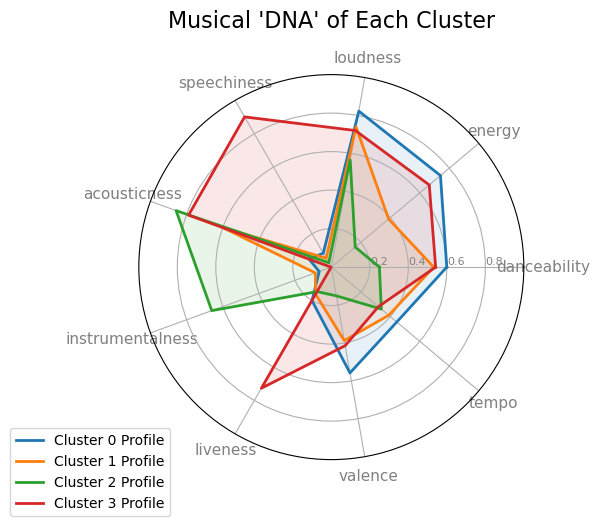

In [110]:
# We use MinMaxScaler so all features are on a 0 to 1 scale for the chart axes
radar_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 
                  'valence', 'tempo']

radar_scaler = MinMaxScaler()
radar_scaled_values = radar_scaler.fit_transform(data[radar_features])
radar_df = pd.DataFrame(radar_scaled_values, columns=radar_features)
radar_df['Cluster'] = data['Cluster'].values

# Calculate the average (mean) profile for each cluster
cluster_profiles = radar_df.groupby('Cluster').mean().reset_index()

def make_radar_chart(df):
    categories = list(df.columns[1:])
    N = len(categories)
    
    # What will be the angle of each axis in the plot?
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Close the circle
    
    fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=dict(polar=True))
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, color='grey', size=11)
    
    # Draw y-axis labels
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"], color="grey", size=8)
    plt.ylim(0,1)
    
    # Colors for the clusters
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Plot each cluster profile
    for i, row in df.iterrows():
        values = row.drop('Cluster').values.flatten().tolist()
        values += values[:1] # Close the circle
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', 
                label=f'Cluster {int(row["Cluster"])} Profile', color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)
    
    plt.title("Musical 'DNA' of Each Cluster", size=16, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.show()

# Generate the plot
make_radar_chart(cluster_profiles)

## Final Cluster Interpretation

Based on the cluster summary and centroid analysis, each cluster can be interpreted according to its dominant audio features. These clusters represent distinct types of songs within the dataset.

### Cluster 0 – Energetic and Danceable Songs
Cluster 0 shows the highest energy (0.82) and danceability (0.76) among all clusters, along with relatively higher tempo, indicating energetic and danceable songs such as pop or electronic music.

### Cluster 1 – Acoustic and Calm Songs
Cluster 1 exhibits the highest acousticness (0.65) and lower energy (0.30) compared to other clusters, along with lower loudness, indicating softer, calmer, and more acoustic tracks such as folk or acoustic music.

### Cluster 2 – Instrumental or Ambient Tracks
Cluster 2 shows the highest instrumentalness (0.70) and low speechiness compared to other clusters, suggesting that these tracks are primarily instrumental or ambient, with minimal or no vocals.

### Cluster 3 – Balanced/Mainstream Songs
Cluster 3 displays mid-range values across most features, including energy, danceability, and valence, compared to other clusters, indicating balanced or mainstream songs that appeal to a wide audience.

### Overall Insights
The clustering results indicate that K-Means has successfully identified meaningful patterns in the dataset by grouping songs with similar audio characteristics. The clear differences between clusters highlight the diversity of musical styles and demonstrate the effectiveness of unsupervised learning in discovering hidden structures within data.